In [1]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt

# Работа с логами

## Загрузка логов

In [2]:
logs = [
 {"src_ip":"192.168.1.10","event":"DNS query"},
 {"src_ip":"192.168.1.10","event":"DNS query"},
 {"src_ip":"192.168.1.10","event":"DNS query"},
 {"src_ip":"45.33.32.156","event":"port scan"},
 {"src_ip":"45.33.32.156","event":"port scan"},
 {"src_ip":"45.33.32.156","event":"port scan"},
 {"src_ip":"8.8.8.8","event":"DNS query"},
 {"src_ip":"1.1.1.1","event":"DNS query"},
 {"src_ip":"1.1.1.1","event":"DNS query"}
]

with open("suricata_logs.json","w") as f:
    json.dump(logs,f)

print("Test logs created")

Test logs created


In [3]:
with open("suricata_logs.json","r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

df

,src_ip,event
0,192.168.1.10,DNS query
1,192.168.1.10,DNS query
2,192.168.1.10,DNS query
3,45.33.32.156,port scan
4,45.33.32.156,port scan
5,45.33.32.156,port scan
6,8.8.8.8,DNS query
7,1.1.1.1,DNS query
8,1.1.1.1,DNS query


## Анализ логов и создание отчета

In [19]:
ip_counts = df["src_ip"].value_counts()

ip_counts

src_ip
192.168.1.10    3
45.33.32.156    3
1.1.1.1         2
8.8.8.8         1
Name: count, dtype: int64

In [20]:
suspicious_ips = ip_counts[ip_counts >= 3]

print("Suspicious IPs:")

suspicious_ips

Suspicious IPs:


src_ip
192.168.1.10    3
45.33.32.156    3
Name: count, dtype: int64

In [21]:
log_report = pd.DataFrame({
    "ip_address": ip_counts.index,
    "event_count": ip_counts.values
})

log_report["threat_level"] = log_report["event_count"].apply(
    lambda x: "HIGH" if x >= 3 else "NORMAL"
)

print("Log analysis report:")
print(log_report)

log_report.to_csv("log_analysis_report.csv", index=False)

Log analysis report:
     ip_address  event_count threat_level
0  192.168.1.10            3         HIGH
1  45.33.32.156            3         HIGH
2       1.1.1.1            2       NORMAL
3       8.8.8.8            1       NORMAL


## Визуализация

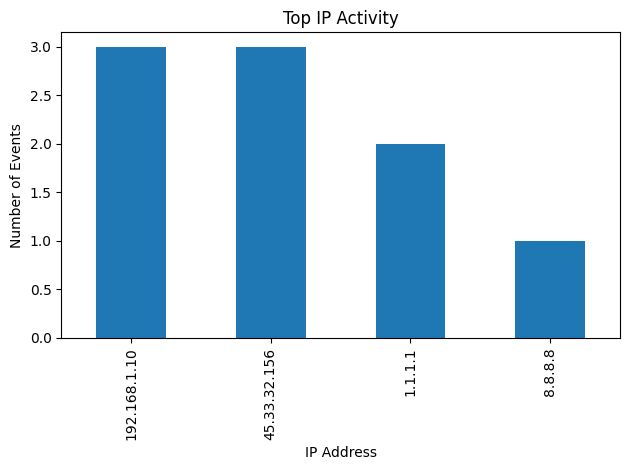

In [22]:
plt.figure()

ip_counts.head(5).plot(kind="bar")

plt.title("Top IP Activity")
plt.xlabel("IP Address")
plt.ylabel("Number of Events")

plt.tight_layout()

plt.savefig("ip_activity_graph.png")

plt.show()

## Имитация реагирования

In [23]:
for ip,count in suspicious_ips.items():

    print("SECURITY ALERT")
    print("Suspicious IP:",ip)
    print("Events:",count)
    print("Action: simulated block\n")

SECURITY ALERT
Suspicious IP: 192.168.1.10
Events: 3
Action: simulated block

SECURITY ALERT
Suspicious IP: 45.33.32.156
Events: 3
Action: simulated block



# Работа с API

## Получение данных из Vulners

In [11]:
import requests

API_KEY = "2585Y4Q7CP2CQ6X63TCZ5J7MK0M97LSHSHI5PPKV1L5MLVQ6U7QIKVA357V3OYGC" #ключи оставлять на гите нельзя, это только для удобства проверки)

url = "https://vulners.com/api/v3/search/lucene/"

headers = {
    "X-Api-Key": API_KEY,
    "Content-Type": "application/json"
}

payload = {
    "query": "bulletinFamily:cve AND apache",
    "size": 10
}

response = requests.post(url, headers=headers, json=payload)

data = response.json()

vulnerabilities = []

search_results = data.get("data", {}).get("search", [])

for item in search_results:

    source = item.get("_source", {})

    score = (
        source.get("cvss3", {})
        .get("cvssV3", {})
        .get("baseScore", 0)
    )

    if score >= 7:

        vulnerabilities.append({
            "cve": source.get("id"),
            "title": source.get("title"),
            "cvss": score
        })

vuln_df = pd.DataFrame(vulnerabilities)

## Анализ данных из Vulners и создание отчета

In [13]:
vuln_report = vuln_df.copy()

vuln_report["severity"] = vuln_report["cvss"].apply(
    lambda x: "CRITICAL" if x >= 9 else
              "HIGH" if x >= 7 else
              "MEDIUM"
)

print("\nVulnerability report:")
print(vuln_report)

vuln_report.to_csv("vulnerability_report.csv", index=False)


Vulnerability report:
             cve          title  cvss severity
0  CVE-2016-0714  CVE-2016-0714   8.8     HIGH
1  CVE-2015-5346  CVE-2015-5346   8.1     HIGH
2  CVE-2016-3090  CVE-2016-3090   8.8     HIGH


# Общий отчет

In [18]:
summary = {
    "Total log events": len(df),
    "Unique IPs": df["src_ip"].nunique(),
    "Suspicious IPs": len(suspicious_ips),
    "Vulnerabilities from Vulners": len(vuln_df)
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric","Value"])

print("\nSecurity metrics:")
print(summary_df)


Security metrics:
                         Metric  Value
0              Total log events      9
1                    Unique IPs      4
2                Suspicious IPs      2
3  Vulnerabilities from Vulners      3


In [24]:
summary_df.to_csv("summary_report.csv", index=False)